<h1 style="font-size: 34px; font-weight: bold; color: blue;">Full ANN Architect</h1>

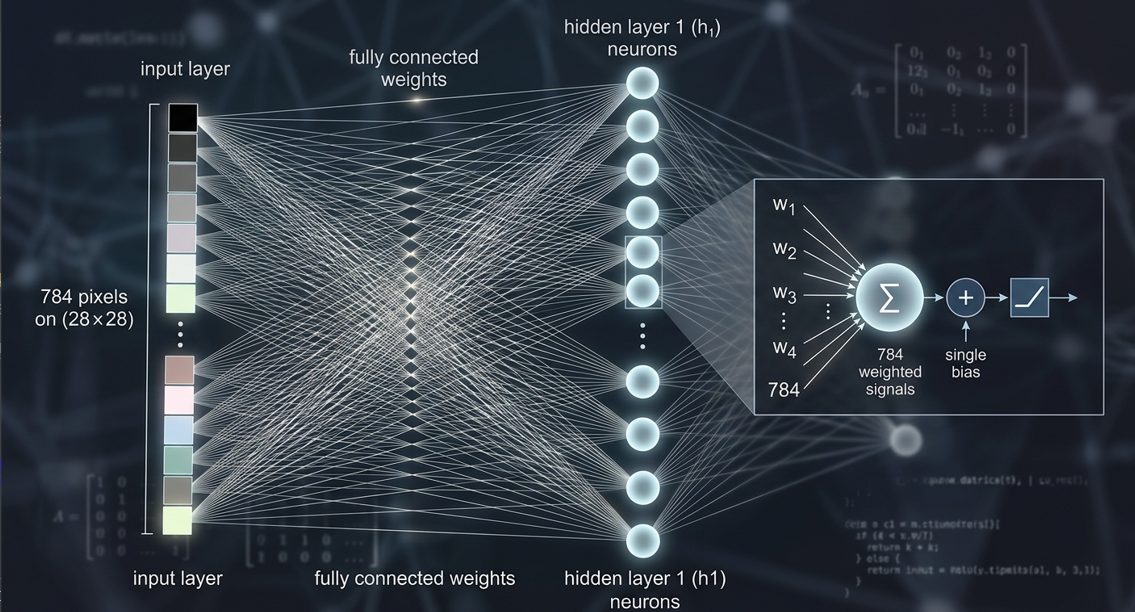

# IMPORTING LIBRARIES

In [2]:
import sys
import importlib
import pandas as pd
import numpy as np
sys.path.append('/kaggle/usr/lib/notebooks/drhanysalem/config/config.py')
import torch.nn as nn
from torchvision.datasets import MNIST, FashionMNIST
from torchvision import transforms

import config
importlib.reload(config)
print(config.BATCH_SIZE)
print(config.LEARNING_RATE)   
config.DROPOUT_RATE

64
0.001


0.21

# Neural Network Class

In [3]:

class NeuralNetwork (nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes,dropout_rate,init_type="he"):
        super().__init__()
        self.flatten=nn.Flatten()
        layers=[]
        ex_layer = input_size
        for hs in hidden_sizes:
            layers.append(nn.Linear(ex_layer, hs))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            ex_layer=hs
        layers.append(nn.Linear(ex_layer, output_size))
        self.classifier=nn.Sequential(*layers)
        self.init_type = init_type.lower()
        self.apply(self._init_weights)
    # Initializing weight using xavier_normal distribution
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            if self.init_type in ('he', "kaiming"): 
            # Fill the input Tensor with values using a Kaiming normal distribution (He method).
                nn.init.kaiming_normal_(module.weight,mode="fan_in",nonlinearity="relu")
            # Fill the input Tensor with values using a Kaiming uniform distribution.
            elif self.init_type == 'he_uniform':
                nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')
            # Fill the input Tensor with values using xavier (Glorot) normal distribution
            elif self.init_type == "xavier":
                nn.init.xavier_normal_(module.weight) # Fill the input Tensor with values using a Xavier normal distribution.
            
            if module.bias is not None:
                nn.init.zeros_(module.bias) # Fill the input Tensor with the scalar value 0.
    def forward (self,x):
        x = self.flatten(x)
        logit = self.classifier(x)
        return(logit)
        

{'BATCH_SIZE': 64, 'NUM_WORKERS': 2, 'INPUT_SIZE': 784, 'HIDDEN_SIZES': [512, 256, 128], 'DROPOUT_RATE': 0.21, 'NUM_CLASSES': 10, 'NUM_EPOCHS': 10, 'LEARNING_RATE': 0.001, 'OPTIMIZER': ['Adam', 'SGD', 'Adam', 'RMSprop']}'

# Loadind Dataset Class

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
print ("libraries imported ...")


class get_dataloader():
    def __init__(
        self,
        dataset_class="MNIST",
        root="./data",
        train=True,
        download=True,
        transform=None,
        shuffle=True,
        train_batch_size=32,
        test_batch_size = 1000,
        train_kwargs=None,
        test_kwargs=None
        
    ):
        self.dataset_class=dataset_class
        self.root=root
        self.train=train
        self.download=download
        self.transform = transform or transforms.ToTensor()
        self.shuffle = shuffle
        self.train_batch_size = train_batch_size
        self.test_batch_size = test_batch_size
        self.train_kwargs =train_kwargs or {}
        self.test_kwargs = test_kwargs or {}
    def loading(self):
        train_dataset = self.dataset_class(
            root = self.root,
            train = self.train,
            download = self.download,
            transform = self.transform,
            **self.train_kwargs
        )
        test_dataset = self.dataset_class(
            root = self.root,
            train = False,
            download = self.download,
            transform = self.transform,
            **self.test_kwargs
        )
        train_loader = DataLoader(
            train_dataset,
            batch_size = self.train_batch_size,
            shuffle = self.shuffle
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size = self. test_batch_size,
            shuffle = False
        )
        return train_loader, test_loader
        
   
     
 

libraries imported ...


# Train and Evaluate

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
class datatrain():
    def __init__(
        self,
        model,
        device = 'cuda',
        optim="Adam",
        scheduler=None,
        learning_rate=0.001        
    ):
        self.device = device if torch.cuda.is_available() and device=="cuda" else "cpu"
        self.model=model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()
        self.lr = learning_rate
        self.optim = self._get_optimizer(optim, self.lr) 
        self.scheduler=self._get_scheduler(scheduler) 
        self.history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_accuracy': []}
        self.best_test_acc = 0.0
    # setting optimzer type.
    def _get_optimizer(self, optimizer_name, learning_rate):
        if optimizer_name == 'SGD':
            return optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9)
        elif optimizer_name == 'Adam':
            return optim.Adam(self.model.parameters(), lr=self.lr)
        elif optimizer_name == 'RMSprop':
            return optim.RMSprop(self.model.parameters(), lr=self.lr)
        else:
            raise ValueError(f"Unsupported optimizer: {optimizer_name}")
    # setting scheduler type
    def _get_scheduler(self, scheduler_name):
        if scheduler_name == 'StepLR':
            return optim.lr_scheduler.StepLR(self.optim, step_size=5, gamma=0.1)
        elif scheduler_name == 'CosineAnnealingLR':
            return optim.lr_scheduler.CosineAnnealingLR(self.optim, T_max=10)
        elif scheduler_name == "ReduceLROnPlateau":
            return optim.lr_scheduler.ReduceLROnPlateau(self.optim,'min',patience=2)
        return None
    # train epoch
    def train_epoch (self,dataloader):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images,labels in tqdm(dataloader, desc="model training"):
            images,labels = images.to(self.device), labels.to(self.device)
            self.optim.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs,labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optim.step()

            # matrics
            running_loss += loss.item()
            _,pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc

    # evaluation of epoch
    def evaluate(self, dataloader):
        self.model.eval()
        all_preds = []
        all_labels = []
        test_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images,labels in tqdm(dataloader,desc="evaluation"):
                images,labels = images.to(self.device),labels.to(self.device)
                outputs=self.model(images)
                loss = self.criterion(outputs,labels)

                # metics
                test_loss += loss.item()
                _,pred = outputs.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # metrics
            test_loss = test_loss / len(dataloader)
            test_accuracy = 100* correct/total
        return test_loss, test_accuracy, all_preds, all_labels
            
    def train (self, train_loader, test_loader, epochs=5):
        
        for epoch in range(epochs):
            print (f"Epoch {epoch+1}/{epochs}")
            # train
            train_loss, train_acc = self.train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            self.history["train_acc"].append(train_acc)
            # eval
            test_loss,test_accuracy,prediction,labels = self.evaluate(test_loader)
            self.history['test_loss'].append(test_loss)
            self.history['test_accuracy'].append(test_accuracy)

            # Learning rate scheduling
            if self.scheduler:
                if hasattr(self.scheduler, 'step') and not isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step()
                elif isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(test_loss)
                    
            self.lr = self.optim.param_groups[0]['lr']
            # printing
            print (f"train loss: {train_loss:.2f} | train accuracy: {train_acc:.2f}% | test loss: {test_loss:.2f} | test accuracy: {test_accuracy:.2f}%")
            print (f"learning rate: {self.lr:.4f}")

            # Save best model
            if test_accuracy > self.best_test_acc:
                self.best_test_acc = test_accuracy
                torch.save(self.model.state_dict(), 'best_model.pt')
                print (f" Model saved with best accuracy: {test_accuracy:.2f}%")
                   # self.model.load_state_dict(torch.load('best_model.pth'))


        return self.history, prediction, labels
            
            

# Model implementation

In [6]:
# Loading MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

loader = get_dataloader(MNIST, transform=transform,train_batch_size=config.BATCH_SIZE)
trainloader, testloader = loader.loading()

# Applying the model
model = NeuralNetwork(config.INPUT_SIZE, config.NUM_CLASSES, config.HIDDEN_SIZES,config.DROPOUT_RATE)
trainer = datatrain(model=model, optim=config.OPTIMIZER[0], learning_rate=config.LEARNING_RATE)
history, preds, labels = trainer.train(trainloader, testloader, epochs=config.NUM_EPOCHS)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 365kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.66MB/s]


Epoch 1/10


evaluation: 100%|██████████| 10/10 [00:02<00:00,  4.86it/s]


train loss: 0.32 | train accuracy: 90.44% | test loss: 0.13 | test accuracy: 96.19%
learning rate: 0.0010
 Model saved with best accuracy: 96.19%
Epoch 2/10


evaluation: 100%|██████████| 10/10 [00:01<00:00,  5.13it/s]


...

train loss: 0.06 | train accuracy: 98.20% | test loss: 0.07 | test accuracy: 98.08%
learning rate: 0.0010
 Model saved with best accuracy: 98.08%
Epoch 9/10


evaluation: 100%|██████████| 10/10 [00:01<00:00,  5.07it/s]


train loss: 0.06 | train accuracy: 98.25% | test loss: 0.07 | test accuracy: 98.22%
learning rate: 0.0010
 Model saved with best accuracy: 98.22%
Epoch 10/10


evaluation: 100%|██████████| 10/10 [00:01<00:00,  5.19it/s]

train loss: 0.05 | train accuracy: 98.45% | test loss: 0.08 | test accuracy: 98.15%
learning rate: 0.0010


showing images: 100%|██████████| 10/10 [00:00<00:00, 115.09it/s]


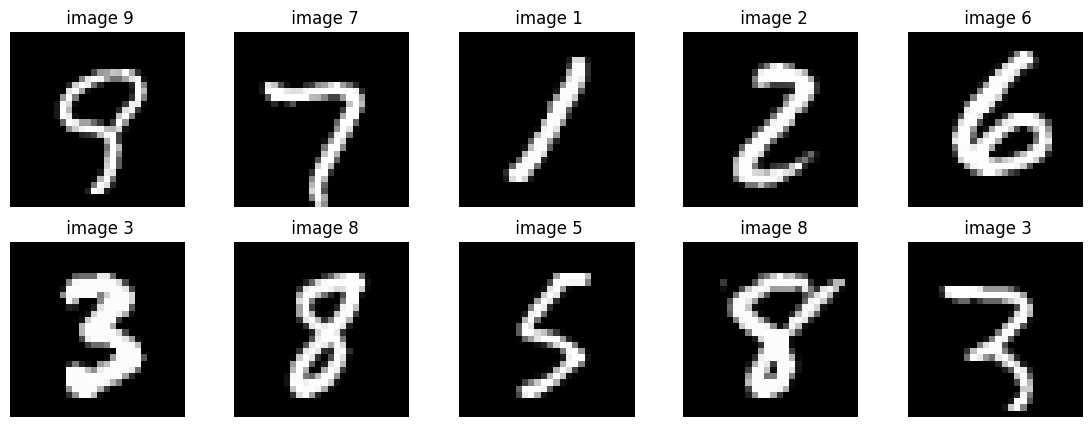

In [9]:
# Visualization image,label=next(iter(train_loader))
image,label=next(iter(trainloader))
plt.figure(figsize=(14,5))
for i in tqdm(range (10),desc="showing images"):
    plt.subplot(2,5,i+1)
    plt.imshow(image[i].squeeze(),cmap="gray")
    plt.title (f" image {label[i]}")
    plt.axis('off')
plt.show() 

In [10]:
# Demonstrating the progress of loss and accuracy (history)
mnist_history = pd.DataFrame(history)
print (mnist_history)

   train_loss  train_acc  test_loss  test_accuracy
0    0.320872  90.443333   0.132271          96.19
1    0.156846  95.473333   0.103316          97.00
2    0.116881  96.656667   0.078755          97.72
3    0.098896  97.125000   0.072562          97.84
4    0.084385  97.608333   0.076852          97.84
5    0.075552  97.808333   0.081452          97.85
6    0.068094  97.951667   0.086267          97.77
7    0.061446  98.198333   0.065691          98.08
8    0.058129  98.255000   0.071069          98.22
9    0.052343  98.448333   0.078445          98.15


In [14]:
# Comparing predictions and labels (y-predict & y-true)
results = pd.DataFrame ({"prediction":preds,"labels":labels})
print (results)

      prediction  labels
0              7       7
1              2       2
2              1       1
3              0       0
4              4       4
...          ...     ...
9995           2       2
9996           3       3
9997           4       4
9998           5       5
9999           6       6

[10000 rows x 2 columns]


In [15]:
# Loading FashionMNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])
loader = get_dataloader(FashionMNIST, transform=transform,train_batch_size=config.BATCH_SIZE)
trainloader, testloader = loader.loading()

# Applying the model
model = NeuralNetwork(config.INPUT_SIZE, config.NUM_CLASSES, config.HIDDEN_SIZES,config.DROPOUT_RATE)
trainer = datatrain(model=model, optim=config.OPTIMIZER[0], learning_rate=config.LEARNING_RATE)
history, preds, labels = trainer.train(trainloader, testloader, epochs=config.NUM_EPOCHS)

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.44MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 44.9MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.63MB/s]


Epoch 1/10


evaluation: 100%|██████████| 10/10 [00:04<00:00,  2.13it/s]


train loss: 0.58 | train accuracy: 79.62% | test loss: 0.43 | test accuracy: 84.52%
learning rate: 0.0010
 Model saved with best accuracy: 84.52%
Epoch 2/10


evaluation: 100%|██████████| 10/10 [00:02<00:00,  4.12it/s]


...

train loss: 0.30 | train accuracy: 89.01% | test loss: 0.35 | test accuracy: 87.84%
learning rate: 0.0010
Epoch 9/10


evaluation: 100%|██████████| 10/10 [00:01<00:00,  5.17it/s]


train loss: 0.30 | train accuracy: 89.19% | test loss: 0.35 | test accuracy: 87.97%
learning rate: 0.0010
 Model saved with best accuracy: 87.97%
Epoch 10/10


evaluation: 100%|██████████| 10/10 [00:01<00:00,  5.07it/s]


train loss: 0.29 | train accuracy: 89.47% | test loss: 0.33 | test accuracy: 88.08%
learning rate: 0.0010
 Model saved with best accuracy: 88.08%


showing images: 100%|██████████| 10/10 [00:00<00:00, 111.86it/s]


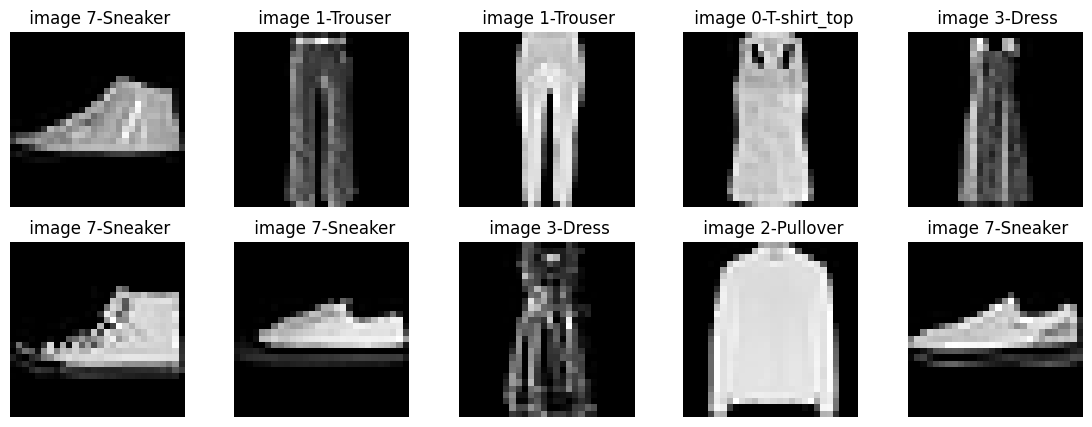

In [19]:
# visualization
FashionMNIST_labels={0: "T-shirt_top",
                     1: "Trouser",
                     2: "Pullover",
                     3: "Dress",
                     4: "Coat",
                     5: "Sandal",
                     6: "Shirt",
                     7: "Sneaker",
                     8: "Bag",
                     9: "Ankle_boot"} # (https://www.mdpi.com/2227-7390/12/20/3174)
image,label=next(iter(trainloader))
plt.figure(figsize=(14,5))
for i in tqdm(range (10),desc="showing images"):
    plt.subplot(2,5,i+1)
    plt.imshow(image[i].squeeze(),cmap="gray")
    plt.title (f" image {label[i]}-{FashionMNIST_labels[int(label[i])]}")
    plt.axis('off')
plt.show() 

In [21]:
# Demonstrating the progresss of loss and accuracy
fashionMNIST_history=pd.DataFrame(history)
print (fashionMNIST_history)

   train_loss  train_acc  test_loss  test_accuracy
0    0.578207  79.616667   0.428047          84.52
1    0.424016  84.788333   0.388305          85.48
2    0.381862  86.373333   0.383590          85.99
3    0.356407  87.201667   0.359992          87.10
4    0.342176  87.620000   0.365701          87.08
5    0.327321  88.136667   0.350875          87.59
6    0.315925  88.411667   0.335038          87.87
7    0.304019  89.011667   0.351277          87.84
8    0.298777  89.185000   0.352351          87.97
9    0.289950  89.468333   0.332319          88.08


In [22]:
# Comparing prediction with the actual labels (y-predict & y_true)
restuls = pd.DataFrame({'prediction':preds,"labels":labels})
print (results)

      prediction  labels
0              7       7
1              2       2
2              1       1
3              0       0
4              4       4
...          ...     ...
9995           2       2
9996           3       3
9997           4       4
9998           5       5
9999           6       6

[10000 rows x 2 columns]
